# Cluster Then Reject: Plant Dataset

Same experiment as `clustering_evaluation_cluster_then_reject.ipynb` but using
embeddings computed from `plant/binning_5.tsv` instead of pre-saved embeddings.

Cluster **all** test points once, then sort by uncertainty (ascending) and
keep only the most confident X%. Rejected points have their cluster labels
set to -1 before evaluation.

In [1]:
import sys, os, csv
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter
from functools import partial

from sklearn.cluster import KMeans
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.pcl import PCLEmbedder
from embedders.uncertaingen import UncertainGenEmbedder
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from datasets.paired_reads import PairedReadsDataset
from clustering.greedy_kmedoid import GreedyKMedoidClusterer
from evaluation.eval_utils import (
    compute_class_center_medium_similarity,
    count_high_quality_clusters,
    align_labels_via_hungarian_algorithm,
)

# ── Config ──
SEED         = 26042024
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_DIR    = '../../models/notebook/unlabeled_exp'
TRAIN_CSV    = '../../data/dnabert/train/train_2m.csv'
TEST_TSV     = '../../data/dnabert/eval/plant/binning_5.tsv'
METRIC       = 'l2'
MIN_BIN_SIZE = 5
K            = 4
DIM          = 256
NUM_WORKERS  = 0

MODEL_NAMES = ['nl', 'hinge', 'bern_nt', 'ug', 'pcl', 'lla']
MODEL_LABELS = {
    'nl': 'NonLinear', 'hinge': 'Hinge', 'bern_nt': 'Bern-NT',
    'ug': 'UncertainGen', 'pcl': 'PCL', 'lla': 'LLA',
}
MODEL_COLORS = {
    'nl': 'gray', 'hinge': 'tab:purple', 'bern_nt': 'tab:olive',
    'ug': 'tab:red', 'pcl': 'tab:blue', 'lla': 'tab:orange',
}
MODEL_MARKERS = {
    'nl': 'x', 'hinge': 'D', 'bern_nt': 'P',
    'ug': 'o', 'pcl': 's', 'lla': '^',
}

COVERAGES = [1.0, 0.99, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

BEST_K_KMEANS = {
    'nl': 500, 'hinge': 450, 'bern_nt': 500,
    'ug': 500, 'pcl': 500, 'lla': 500,
}
BEST_PCA_DIM = 16
DPGMM_MAX_COMPONENTS = 500

print(f'Device: {DEVICE}')
print(f'Coverages ({len(COVERAGES)}): {[f"{c:.0%}" for c in COVERAGES]}')

Device: cuda
Coverages (10): ['100%', '99%', '90%', '80%', '70%', '60%', '50%', '40%', '30%', '20%']


## 1. Load Models

In [2]:
set_seed(SEED)

# ── NonLinear (bern) ──
model_nl = NonLinearEmbedder.load(
    os.path.join(MODEL_DIR, 'nonlinear_unlabeled.model'), device=DEVICE)
print('NonLinear loaded')

# ── Hinge ──
model_hinge = NonLinearEmbedder.load(
    os.path.join(MODEL_DIR, 'hinge_unlabeled.model'), device=DEVICE)
print('Hinge loaded')

# ── Bern-NT ──
model_bern_nt = NonLinearEmbedder.load(
    os.path.join(MODEL_DIR, 'bern_nt_unlabeled.model'), device=DEVICE)
print('Bern-NT loaded')

# ── UncertainGen ──
model_ug = UncertainGenEmbedder.load(
    os.path.join(MODEL_DIR, 'uncertaingen_unlabeled.model'), device=DEVICE)
print('UncertainGen loaded')

# ── PCL ──
model_pcl = PCLEmbedder.load(
    os.path.join(MODEL_DIR, 'pcl_unlabeled2.model'), device=DEVICE)
print('PCL loaded')

# ── LLA (wraps NonLinear) ──
LLA_PATH = os.path.join(MODEL_DIR, 'lla_state.pt')
model_lla = LaplaceLastLayerEmbedder(model_nl)
lla_state = torch.load(LLA_PATH, map_location=DEVICE, weights_only=True)
model_lla.Q_A = lla_state['Q_A']
model_lla.Q_B = lla_state['Q_B']
model_lla.S_A = lla_state['S_A']
model_lla.S_B = lla_state['S_B']
model_lla.prior_precision = lla_state['prior_precision']
model_lla.n_data = lla_state['n_data']
model_lla._fitted = True
print(f'LLA loaded (prior={model_lla.prior_precision:.2f})')

NonLinear loaded
Hinge loaded
Bern-NT loaded
UncertainGen loaded
PCL loaded
LLA loaded (prior=4114.23)


## 2. Load Plant Dataset & Compute Embeddings

In [3]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))

# ── Load plant/binning_5.tsv ──
with open(TEST_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    _header = next(reader)
    all_rows = list(reader)

all_seqs       = [r[0] for r in all_rows]
all_labels_str = [r[1] for r in all_rows]

# ── Subsample 20k val + 20k test ──
SUBSAMPLE_VAL  = 20_000
SUBSAMPLE_TEST = 20_000
SUBSAMPLE_TOTAL = SUBSAMPLE_VAL + SUBSAMPLE_TEST

rng = np.random.RandomState(SEED)
n_total = len(all_seqs)
if SUBSAMPLE_TOTAL < n_total:
    subset_idx = rng.choice(n_total, size=SUBSAMPLE_TOTAL, replace=False)
    sub_seqs       = [all_seqs[i] for i in subset_idx]
    sub_labels_str = [all_labels_str[i] for i in subset_idx]
else:
    sub_seqs       = all_seqs
    sub_labels_str = all_labels_str
    print(f'Warning: dataset has only {n_total} sequences, using all instead of {SUBSAMPLE_TOTAL}')

# ── Remove singleton classes ──
label_counts = Counter(sub_labels_str)
singleton_classes = {l for l, c in label_counts.items() if c < 2}
if singleton_classes:
    print(f'Removing {len(singleton_classes)} singleton classes from subsample')
    keep = [(s, l) for s, l in zip(sub_seqs, sub_labels_str) if l not in singleton_classes]
    sub_seqs       = [s for s, l in keep]
    sub_labels_str = [l for s, l in keep]
    print(f'  Kept {len(sub_seqs)} / {SUBSAMPLE_TOTAL} sequences')

# ── Stratified 50/50 split ──
val_seqs, test_seqs, val_labels_str, test_labels_str = train_test_split(
    sub_seqs, sub_labels_str, test_size=0.5, random_state=SEED, stratify=sub_labels_str)

unique_labels = sorted(set(sub_labels_str))
lab2id        = {l: i for i, l in enumerate(unique_labels)}
n_species     = len(unique_labels)

val_labels  = np.array([lab2id[l] for l in val_labels_str])
test_labels = np.array([lab2id[l] for l in test_labels_str])

print(f'Loaded {len(all_rows)} sequences from plant/binning_5.tsv')
print(f'Validation: {len(val_seqs)} | Test: {len(test_seqs)} | Species: {n_species}')

Removing 10 singleton classes from subsample
  Kept 39990 / 40000 sequences
Loaded 112507 sequences from plant/binning_5.tsv
Validation: 19995 | Test: 19995 | Species: 312


In [4]:
# ── Compute embeddings ──
models = {
    'nl': model_nl, 'hinge': model_hinge, 'bern_nt': model_bern_nt,
    'ug': model_ug, 'pcl': model_pcl, 'lla': model_lla,
}

val_embs  = {}
test_embs = {}
for m in MODEL_NAMES:
    print(f'Embedding {MODEL_LABELS[m]}...')
    val_embs[m]  = models[m].embed(val_seqs)
    test_embs[m] = models[m].embed(test_seqs)
    print(f'  val: {val_embs[m].mean.shape}  test: {test_embs[m].mean.shape}')

print('Done.')

Embedding NonLinear...
  val: (19995, 256)  test: (19995, 256)
Embedding Hinge...
  val: (19995, 256)  test: (19995, 256)
Embedding Bern-NT...
  val: (19995, 256)  test: (19995, 256)
Embedding UncertainGen...
  val: (19995, 256)  test: (19995, 256)
Embedding PCL...
  val: (19995, 256)  test: (19995, 256)
Embedding LLA...
  val: (19995, 256)  test: (19995, 256)
Done.


## 3. Thresholds, Uncertainty & Sort Orders

In [5]:
thresholds = {}
scales = {}

for m in MODEL_NAMES:
    e = val_embs[m]
    kwargs = dict(metric=METRIC)
    if m == 'ug':
        kwargs['variances'] = e.variance
        kwargs['k_form'] = 'identity'
        kwargs['alpha'] = 1.0
    elif m == 'pcl':
        kwargs['kappas'] = e.kappa
        kwargs['k_form'] = 'cosine_direct'
        kwargs['alpha'] = 1.0

    pv, sc = compute_class_center_medium_similarity(
        e.point_estimate, val_labels, **kwargs)

    idx = -1 if m == 'pcl' else -3
    thresholds[m] = pv[idx]
    scales[m] = sc

# Define uncertainty per model
uncertainties = {}
rng = np.random.RandomState(SEED)
for m in MODEL_NAMES:
    e = test_embs[m]
    if m == 'ug':
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'lla':
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'pcl':
        uncertainties[m] = 1.0 / np.clip(e.kappa, 1e-6, None)
    else:
        uncertainties[m] = rng.rand(len(test_labels))

sort_orders = {m: np.argsort(uncertainties[m]) for m in MODEL_NAMES}

print('Uncertainty sources:')
for m in MODEL_NAMES:
    src = 'mean(var)' if m in ('ug', 'lla') else '1/kappa' if m == 'pcl' else 'random'
    print(f'  {MODEL_LABELS[m]:>12s}: {src}  '
          f'range=[{uncertainties[m].min():.5f}, {uncertainties[m].max():.5f}]')

Auto-calibrated scale: 0.833593 (median raw distance: 0.8315)
Percentile values: [0.18246126481946198, 0.2850089292577545, 0.3628007072675549, 0.4336601097340178, 0.4999999783326089, 0.5680569848993684, 0.6399437112349813, 0.7185140180395728, 0.8096527992461493]
Auto-calibrated scale: 2.403772 (median raw distance: 0.2884)
Percentile values: [0.1895899872179585, 0.29307704734811774, 0.37074371582294197, 0.43687016845834753, 0.49999996326560103, 0.5643182372210137, 0.6345338716927652, 0.716493066511263, 0.8178716171832618]
Auto-calibrated scale: 1.400894 (median raw distance: 0.4948)
Percentile values: [0.22159223751161006, 0.31792246029972404, 0.38686869669398805, 0.4448130068940248, 0.5000000094862087, 0.559359363276627, 0.6260111229661646, 0.7040728019399869, 0.8037604758812361]
Auto-calibrated scale: 0.754433 (median raw distance: 0.9188)
Percentile values: [0.31026124954223633, 0.37135031819343567, 0.41529136896133423, 0.45545339584350586, 0.5, 0.569263219833374, 0.6553699374198914

## 4. Cluster All Points Once

In [6]:
N = len(test_labels)

# ── Greedy KMedoid ──
greedy_full_preds = {}
print('=== Greedy KMedoid ===')
for m in MODEL_NAMES:
    e = test_embs[m]
    if m in ('ug', 'lla'):
        emb_input = EmbeddingResult(mean=e.mean)
    else:
        emb_input = e

    kwargs = dict(metric=METRIC, min_bin_size=MIN_BIN_SIZE, scale=scales[m])
    if m == 'pcl':
        kwargs['k_form'] = 'cosine_direct'
        kwargs['alpha'] = 1.0

    gkmed = GreedyKMedoidClusterer(**kwargs)
    pred = gkmed.fit_predict(emb_input, min_similarity=thresholds[m])
    greedy_full_preds[m] = pred

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s}: k={n_clusters:4d}  assigned={assigned:5d}/{N}')

# ── KMeans ──
kmeans_full_preds = {}
print('\n=== KMeans ===')
for m in MODEL_NAMES:
    X = test_embs[m].point_estimate
    best_k = BEST_K_KMEANS[m]
    km = KMeans(n_clusters=best_k, random_state=SEED, n_init=5, max_iter=300)
    pred = km.fit_predict(X)

    counts = Counter(pred)
    small = {c for c, n in counts.items() if n < MIN_BIN_SIZE}
    if small:
        pred = np.where(np.isin(pred, list(small)), -1, pred)

    kmeans_full_preds[m] = pred

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s} (k={best_k}): clusters={n_clusters:4d}  assigned={assigned:5d}/{N}')

# ── DPGMM ──
dpgmm_full_preds = {}
dpgmm_fitted = {}
print('\n=== DPGMM ===')
for m in MODEL_NAMES:
    X = test_embs[m].point_estimate
    pca_dim = min(BEST_PCA_DIM, X.shape[0] - 1, X.shape[1])
    pca_obj = PCA(n_components=pca_dim, random_state=SEED)
    X_pca = pca_obj.fit_transform(X)

    n_comp = min(DPGMM_MAX_COMPONENTS, N - 1)
    bgm = BayesianGaussianMixture(
        n_components=n_comp,
        covariance_type='diag',
        weight_concentration_prior_type='dirichlet_distribution',
        weight_concentration_prior=1000,
        random_state=SEED,
        max_iter=500,
        n_init=1,
    )
    pred = bgm.fit_predict(X_pca)

    counts = Counter(pred)
    small = {c for c, n in counts.items() if n < MIN_BIN_SIZE}
    if small:
        pred = np.where(np.isin(pred, list(small)), -1, pred)

    dpgmm_full_preds[m] = pred
    dpgmm_fitted[m] = {'bgm': bgm, 'pca': pca_obj}

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s}: clusters={n_clusters:4d}  assigned={assigned:5d}/{N}')

=== Greedy KMedoid ===
GreedyKMedoid: 1000 iterations, 601 clusters (after min_bin_size=5)
     NonLinear: k= 601  assigned=16657/19995
GreedyKMedoid: 1000 iterations, 561 clusters (after min_bin_size=5)
         Hinge: k= 561  assigned=14245/19995
GreedyKMedoid: 1000 iterations, 502 clusters (after min_bin_size=5)
       Bern-NT: k= 502  assigned=11921/19995
GreedyKMedoid: 1000 iterations, 596 clusters (after min_bin_size=5)
  UncertainGen: k= 596  assigned=17054/19995


 Computing vMF similarity │██████████████████████████████│ 40/40 [00:01<00:00]


GreedyKMedoid: 1000 iterations, 637 clusters (after min_bin_size=5)
           PCL: k= 637  assigned=15610/19995
GreedyKMedoid: 1000 iterations, 601 clusters (after min_bin_size=5)
           LLA: k= 601  assigned=16657/19995

=== KMeans ===
     NonLinear (k=500): clusters= 499  assigned=19993/19995
         Hinge (k=450): clusters= 426  assigned=19946/19995
       Bern-NT (k=500): clusters= 443  assigned=19883/19995
  UncertainGen (k=500): clusters= 499  assigned=19993/19995
           PCL (k=500): clusters= 500  assigned=19995/19995
           LLA (k=500): clusters= 499  assigned=19993/19995

=== DPGMM ===


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


     NonLinear: clusters= 155  assigned=19932/19995


...

  UncertainGen: clusters= 155  assigned=19932/19995


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


           PCL: clusters= 170  assigned=19916/19995


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


           LLA: clusters= 155  assigned=19932/19995


## 5. Apply Rejection at Each Coverage Level

In [7]:
def extract_metrics(r):
    return {
        'acc': r['accuracy'],
        'precision': r['precision_counts'][8] if len(r['precision_counts']) > 8 else 0,
        'recall': r['recall_counts'][8] if len(r['recall_counts']) > 8 else 0,
        'f1': r['f1_counts'][8] if len(r['f1_counts']) > 8 else 0,
    }

all_full_preds = {
    'Greedy KMedoid': greedy_full_preds,
    'KMeans': kmeans_full_preds,
    'DPGMM': dpgmm_full_preds,
}

method_curves = {method: {m: [] for m in MODEL_NAMES} for method in all_full_preds}

for method, full_preds in all_full_preds.items():
    print(f'\n===== {method} =====')
    for m in MODEL_NAMES:
        order = sort_orders[m]
        pred_all = full_preds[m]
        print(f'\n  {MODEL_LABELS[m]}:')

        # Compute alignment ONCE on full (pre-rejection) predictions
        full_mask = pred_all != -1
        if full_mask.any():
            fixed_alignment = align_labels_via_hungarian_algorithm(
                test_labels[full_mask], pred_all[full_mask]
            )
        else:
            fixed_alignment = {}

        for cov in COVERAGES:
            k_keep = max(1, int(N * cov))
            keep_set = set(order[:k_keep].tolist())

            pred_masked = np.where(
                np.isin(np.arange(N), list(keep_set)),
                pred_all,
                -1,
            )

            # --- Discard mode ---
            keep_idx = order[:k_keep]
            sub_labels = test_labels[keep_idx]
            sub_preds = pred_masked[keep_idx]
            r_discard = count_high_quality_clusters(
                sub_labels, sub_preds, mode='discard',
                precomputed_alignment=fixed_alignment)

            # --- Garbage mode ---
            r_garbage = count_high_quality_clusters(
                test_labels, pred_masked, mode='garbage',
                precomputed_alignment=fixed_alignment)

            # --- Rejected subset ---
            reject_idx = order[k_keep:]
            if len(reject_idx) > 0:
                rej_labels = test_labels[reject_idx]
                rej_preds = pred_all[reject_idx]
                r_rejected = count_high_quality_clusters(
                    rej_labels, rej_preds, mode='discard',
                    precomputed_alignment=fixed_alignment)
                rejected_metrics = extract_metrics(r_rejected)
            else:
                rejected_metrics = {'acc': 0.0, 'precision': 0, 'recall': 0, 'f1': 0}

            n_clusters = len(set(sub_preds[sub_preds != -1].tolist())) if (sub_preds != -1).any() else 0
            assigned = int((sub_preds != -1).sum())

            method_curves[method][m].append({
                'coverage': cov, 'n_keep': k_keep,
                'k': n_clusters, 'assigned': assigned,
                'r': r_discard,
                'discard': extract_metrics(r_discard),
                'garbage': extract_metrics(r_garbage),
                'rejected': rejected_metrics,
            })
            d = extract_metrics(r_discard)
            g = extract_metrics(r_garbage)
            print(f'    cov={cov:.0%}  k={n_clusters:4d}  '
                  f'discard[F1>0.9={d["f1"]:3d} ACC={d["acc"]:.3f}]  '
                  f'garbage[F1>0.9={g["f1"]:3d} ACC={g["acc"]:.3f}]')


===== Greedy KMedoid =====

  NonLinear:
    cov=100%  k= 601  discard[F1>0.9=  6 ACC=0.199]  garbage[F1>0.9=  2 ACC=0.166]
    cov=99%  k= 601  discard[F1>0.9=  6 ACC=0.199]  garbage[F1>0.9=  1 ACC=0.165]
    cov=90%  k= 601  discard[F1>0.9=  6 ACC=0.198]  garbage[F1>0.9=  1 ACC=0.149]
    cov=80%  k= 601  discard[F1>0.9=  5 ACC=0.198]  garbage[F1>0.9=  0 ACC=0.132]
    cov=70%  k= 601  discard[F1>0.9=  5 ACC=0.198]  garbage[F1>0.9=  0 ACC=0.116]
    cov=60%  k= 600  discard[F1>0.9=  5 ACC=0.199]  garbage[F1>0.9=  0 ACC=0.100]
    cov=50%  k= 598  discard[F1>0.9=  6 ACC=0.200]  garbage[F1>0.9=  0 ACC=0.083]
    cov=40%  k= 593  discard[F1>0.9=  6 ACC=0.199]  garbage[F1>0.9=  0 ACC=0.066]
    cov=30%  k= 575  discard[F1>0.9=  9 ACC=0.195]  garbage[F1>0.9=  0 ACC=0.049]
    cov=20%  k= 539  discard[F1>0.9=  9 ACC=0.193]  garbage[F1>0.9=  0 ACC=0.032]

  Hinge:
    cov=100%  k= 561  discard[F1>0.9=  8 ACC=0.243]  garbage[F1>0.9=  3 ACC=0.173]
    cov=99%  k= 561  discard[F1>0.9=  8 ACC=

## 5b. DPGMM: Max-Responsibility Rejection

In [8]:
dpgmm_maxresp_curves = {m: [] for m in MODEL_NAMES}

for m in MODEL_NAMES:
    bgm = dpgmm_fitted[m]['bgm']
    pca_obj = dpgmm_fitted[m]['pca']
    pred_all = dpgmm_full_preds[m]

    # Compute alignment ONCE on full DPGMM predictions
    full_mask = pred_all != -1
    if full_mask.any():
        fixed_alignment = align_labels_via_hungarian_algorithm(
            test_labels[full_mask], pred_all[full_mask]
        )
    else:
        fixed_alignment = {}

    X_pca = pca_obj.transform(test_embs[m].point_estimate)
    resp = bgm.predict_proba(X_pca)
    max_resp = resp.max(axis=1)

    order_mr = np.argsort(-max_resp)

    print(f'{MODEL_LABELS[m]:>12s}: max_resp range=[{max_resp.min():.4f}, {max_resp.max():.4f}]')

    for cov in COVERAGES:
        k_keep = max(1, int(N * cov))

        keep_idx = order_mr[:k_keep]
        keep_set = set(keep_idx.tolist())

        pred_masked = np.where(
            np.isin(np.arange(N), list(keep_set)),
            pred_all,
            -1,
        )

        sub_labels = test_labels[keep_idx]
        sub_preds = pred_masked[keep_idx]
        r_discard = count_high_quality_clusters(
            sub_labels, sub_preds, mode='discard',
            precomputed_alignment=fixed_alignment)

        r_garbage = count_high_quality_clusters(
            test_labels, pred_masked, mode='garbage',
            precomputed_alignment=fixed_alignment)

        reject_idx = order_mr[k_keep:]
        if len(reject_idx) > 0:
            rej_labels = test_labels[reject_idx]
            rej_preds = pred_all[reject_idx]
            r_rejected = count_high_quality_clusters(
                rej_labels, rej_preds, mode='discard',
                precomputed_alignment=fixed_alignment)
            rejected_metrics = extract_metrics(r_rejected)
        else:
            rejected_metrics = {'acc': 0.0, 'precision': 0, 'recall': 0, 'f1': 0}

        n_clusters = len(set(sub_preds[sub_preds != -1].tolist())) if (sub_preds != -1).any() else 0
        assigned = int((sub_preds != -1).sum())

        dpgmm_maxresp_curves[m].append({
            'coverage': cov, 'n_keep': k_keep,
            'k': n_clusters, 'assigned': assigned,
            'r': r_discard,
            'discard': extract_metrics(r_discard),
            'garbage': extract_metrics(r_garbage),
            'rejected': rejected_metrics,
        })
        d = extract_metrics(r_discard)
        g = extract_metrics(r_garbage)
        print(f'    cov={cov:.0%}  n={k_keep:5d}  k={n_clusters:4d}  '
              f'discard[F1>0.9={d["f1"]:3d} ACC={d["acc"]:.3f}]  '
              f'garbage[F1>0.9={g["f1"]:3d} ACC={g["acc"]:.3f}]')

method_curves['DPGMM (max-resp)'] = dpgmm_maxresp_curves

   NonLinear: max_resp range=[0.1085, 1.0000]
    cov=100%  n=19995  k= 155  discard[F1>0.9=  2 ACC=0.201]  garbage[F1>0.9=  2 ACC=0.200]
    cov=99%  n=19795  k= 155  discard[F1>0.9=  2 ACC=0.203]  garbage[F1>0.9=  2 ACC=0.200]
    cov=90%  n=17995  k= 155  discard[F1>0.9=  2 ACC=0.217]  garbage[F1>0.9=  2 ACC=0.194]
    cov=80%  n=15996  k= 155  discard[F1>0.9=  2 ACC=0.232]  garbage[F1>0.9=  2 ACC=0.185]
    cov=70%  n=13996  k= 155  discard[F1>0.9=  3 ACC=0.249]  garbage[F1>0.9=  2 ACC=0.173]
    cov=60%  n=11997  k= 155  discard[F1>0.9=  4 ACC=0.269]  garbage[F1>0.9=  2 ACC=0.160]
    cov=50%  n= 9997  k= 155  discard[F1>0.9=  6 ACC=0.292]  garbage[F1>0.9=  2 ACC=0.145]
    cov=40%  n= 7998  k= 155  discard[F1>0.9=  6 ACC=0.326]  garbage[F1>0.9=  2 ACC=0.129]
    cov=30%  n= 5998  k= 155  discard[F1>0.9= 10 ACC=0.370]  garbage[F1>0.9=  2 ACC=0.110]
    cov=20%  n= 3999  k= 155  discard[F1>0.9= 12 ACC=0.442]  garbage[F1>0.9=  2 ACC=0.087]
       Hinge: max_resp range=[0.1477, 1.000

## 6. Comparison Plots: Discard vs Garbage

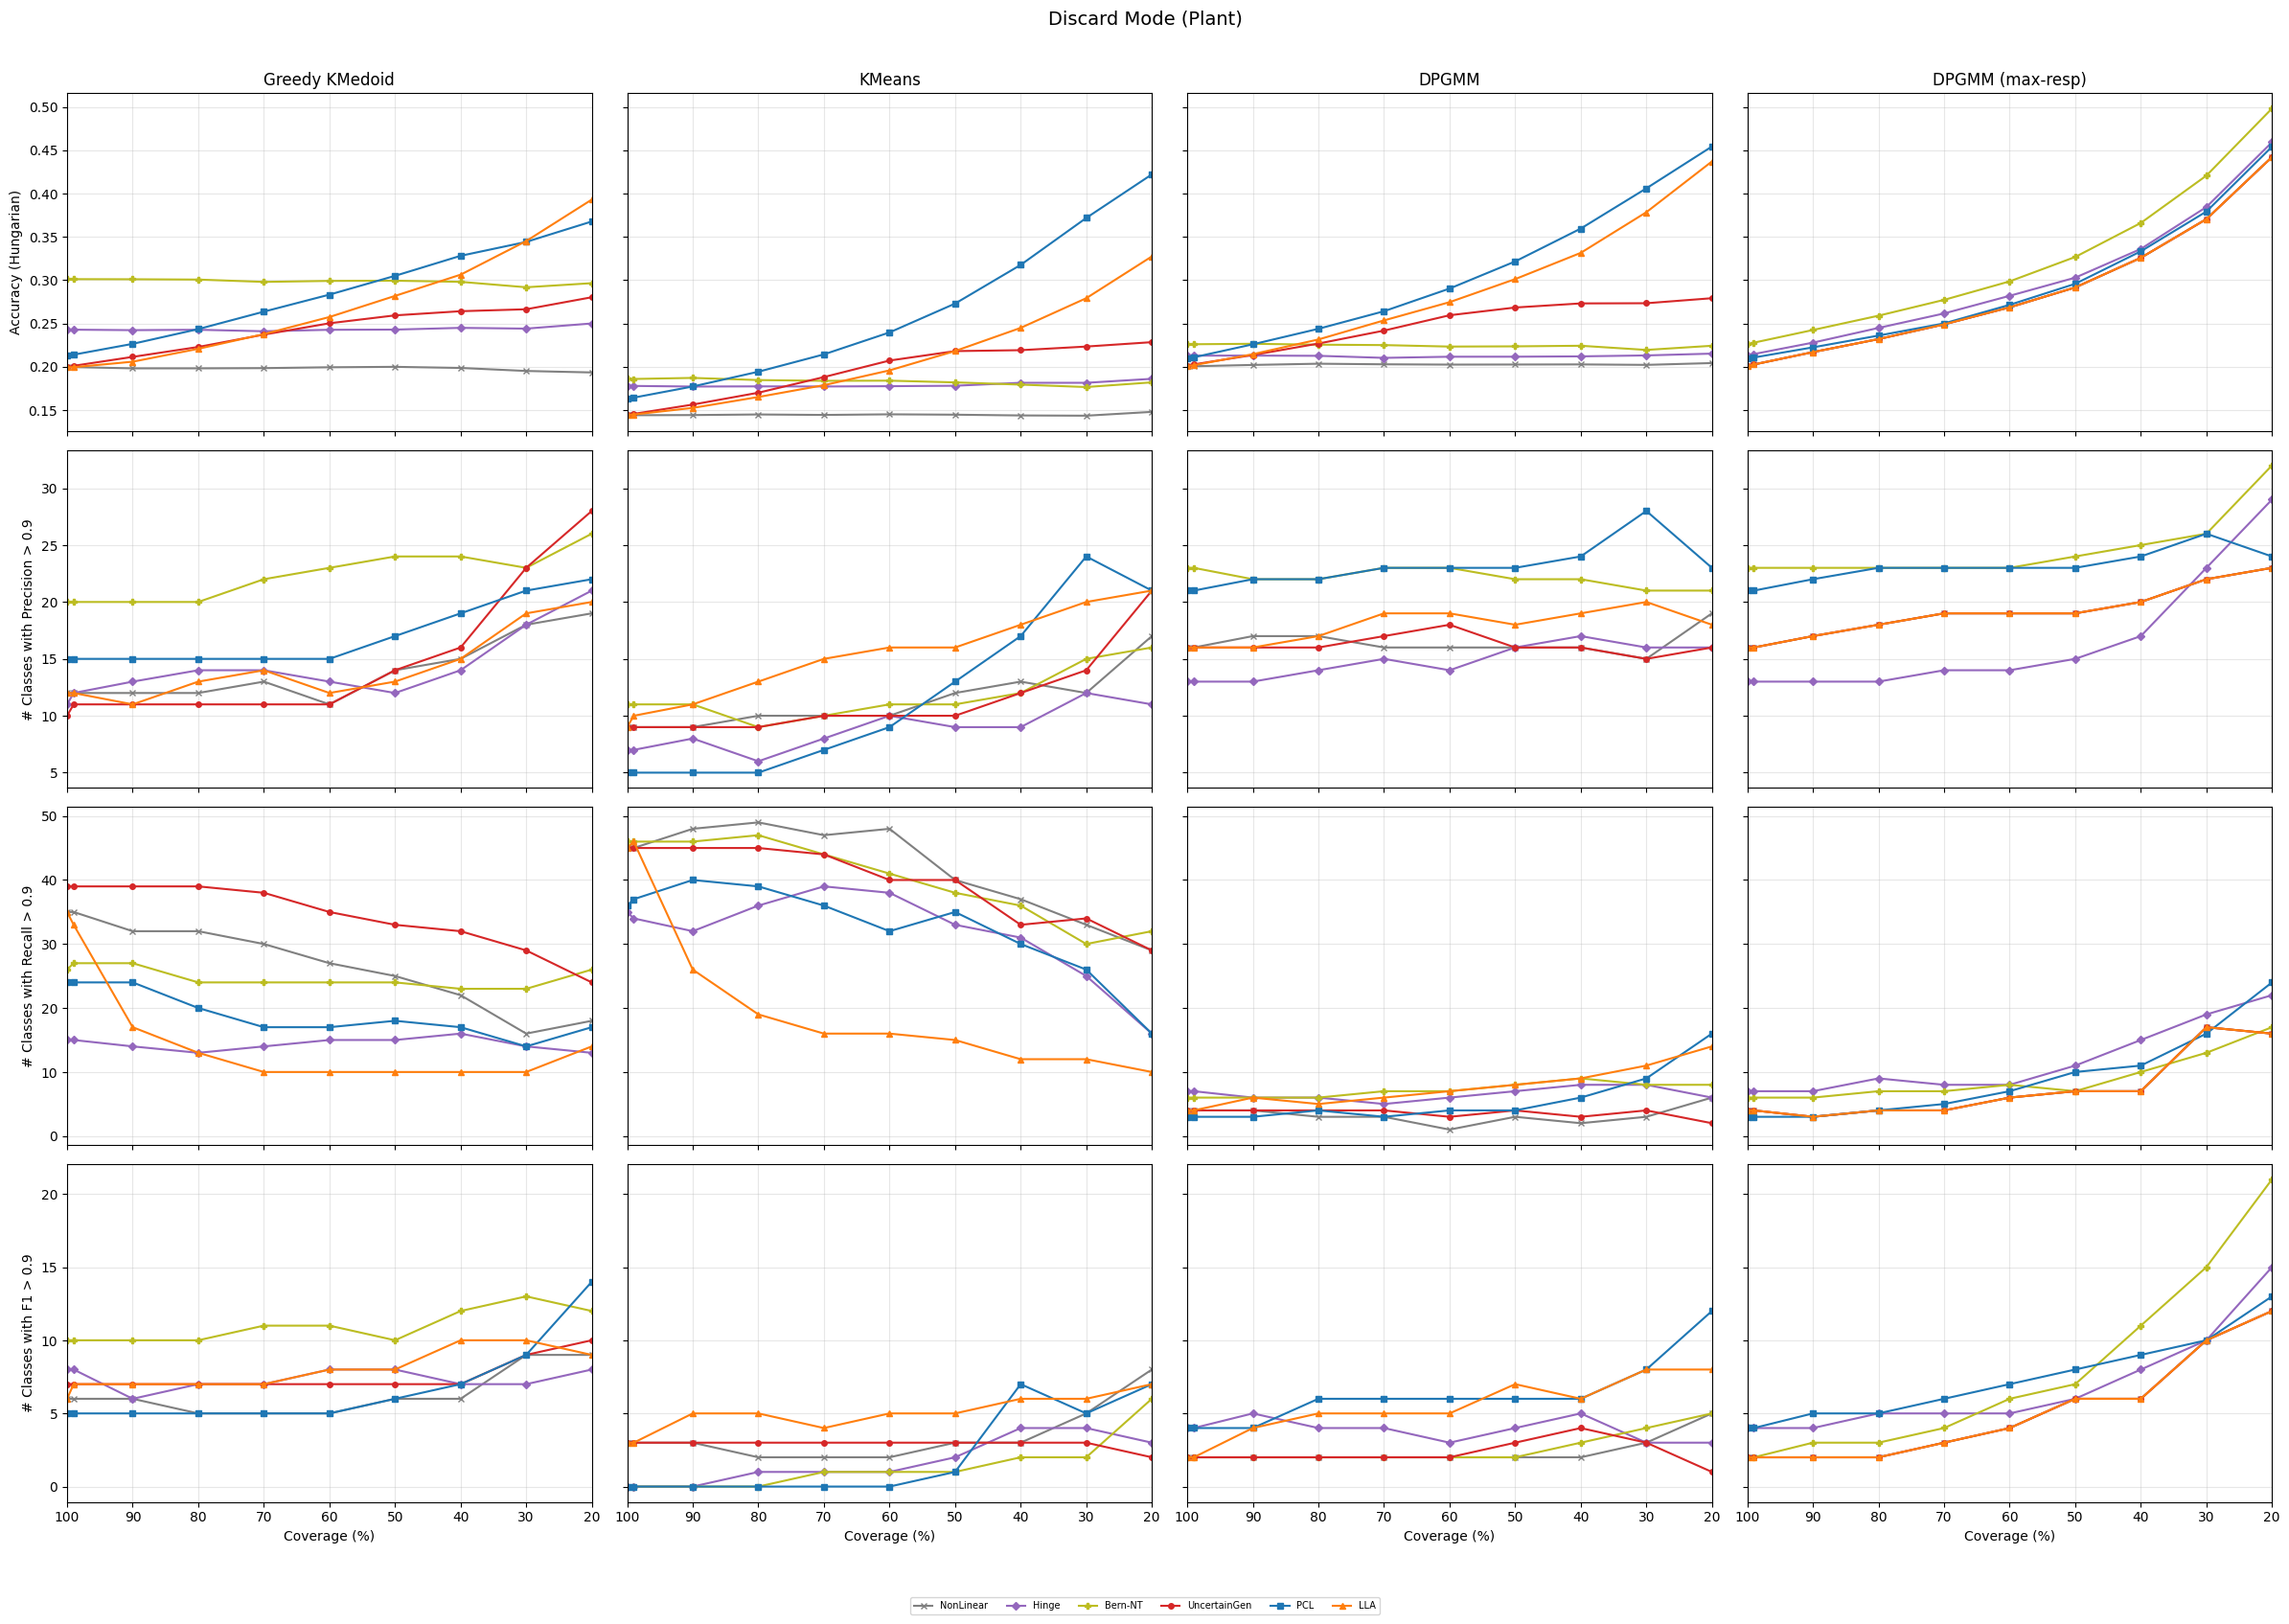

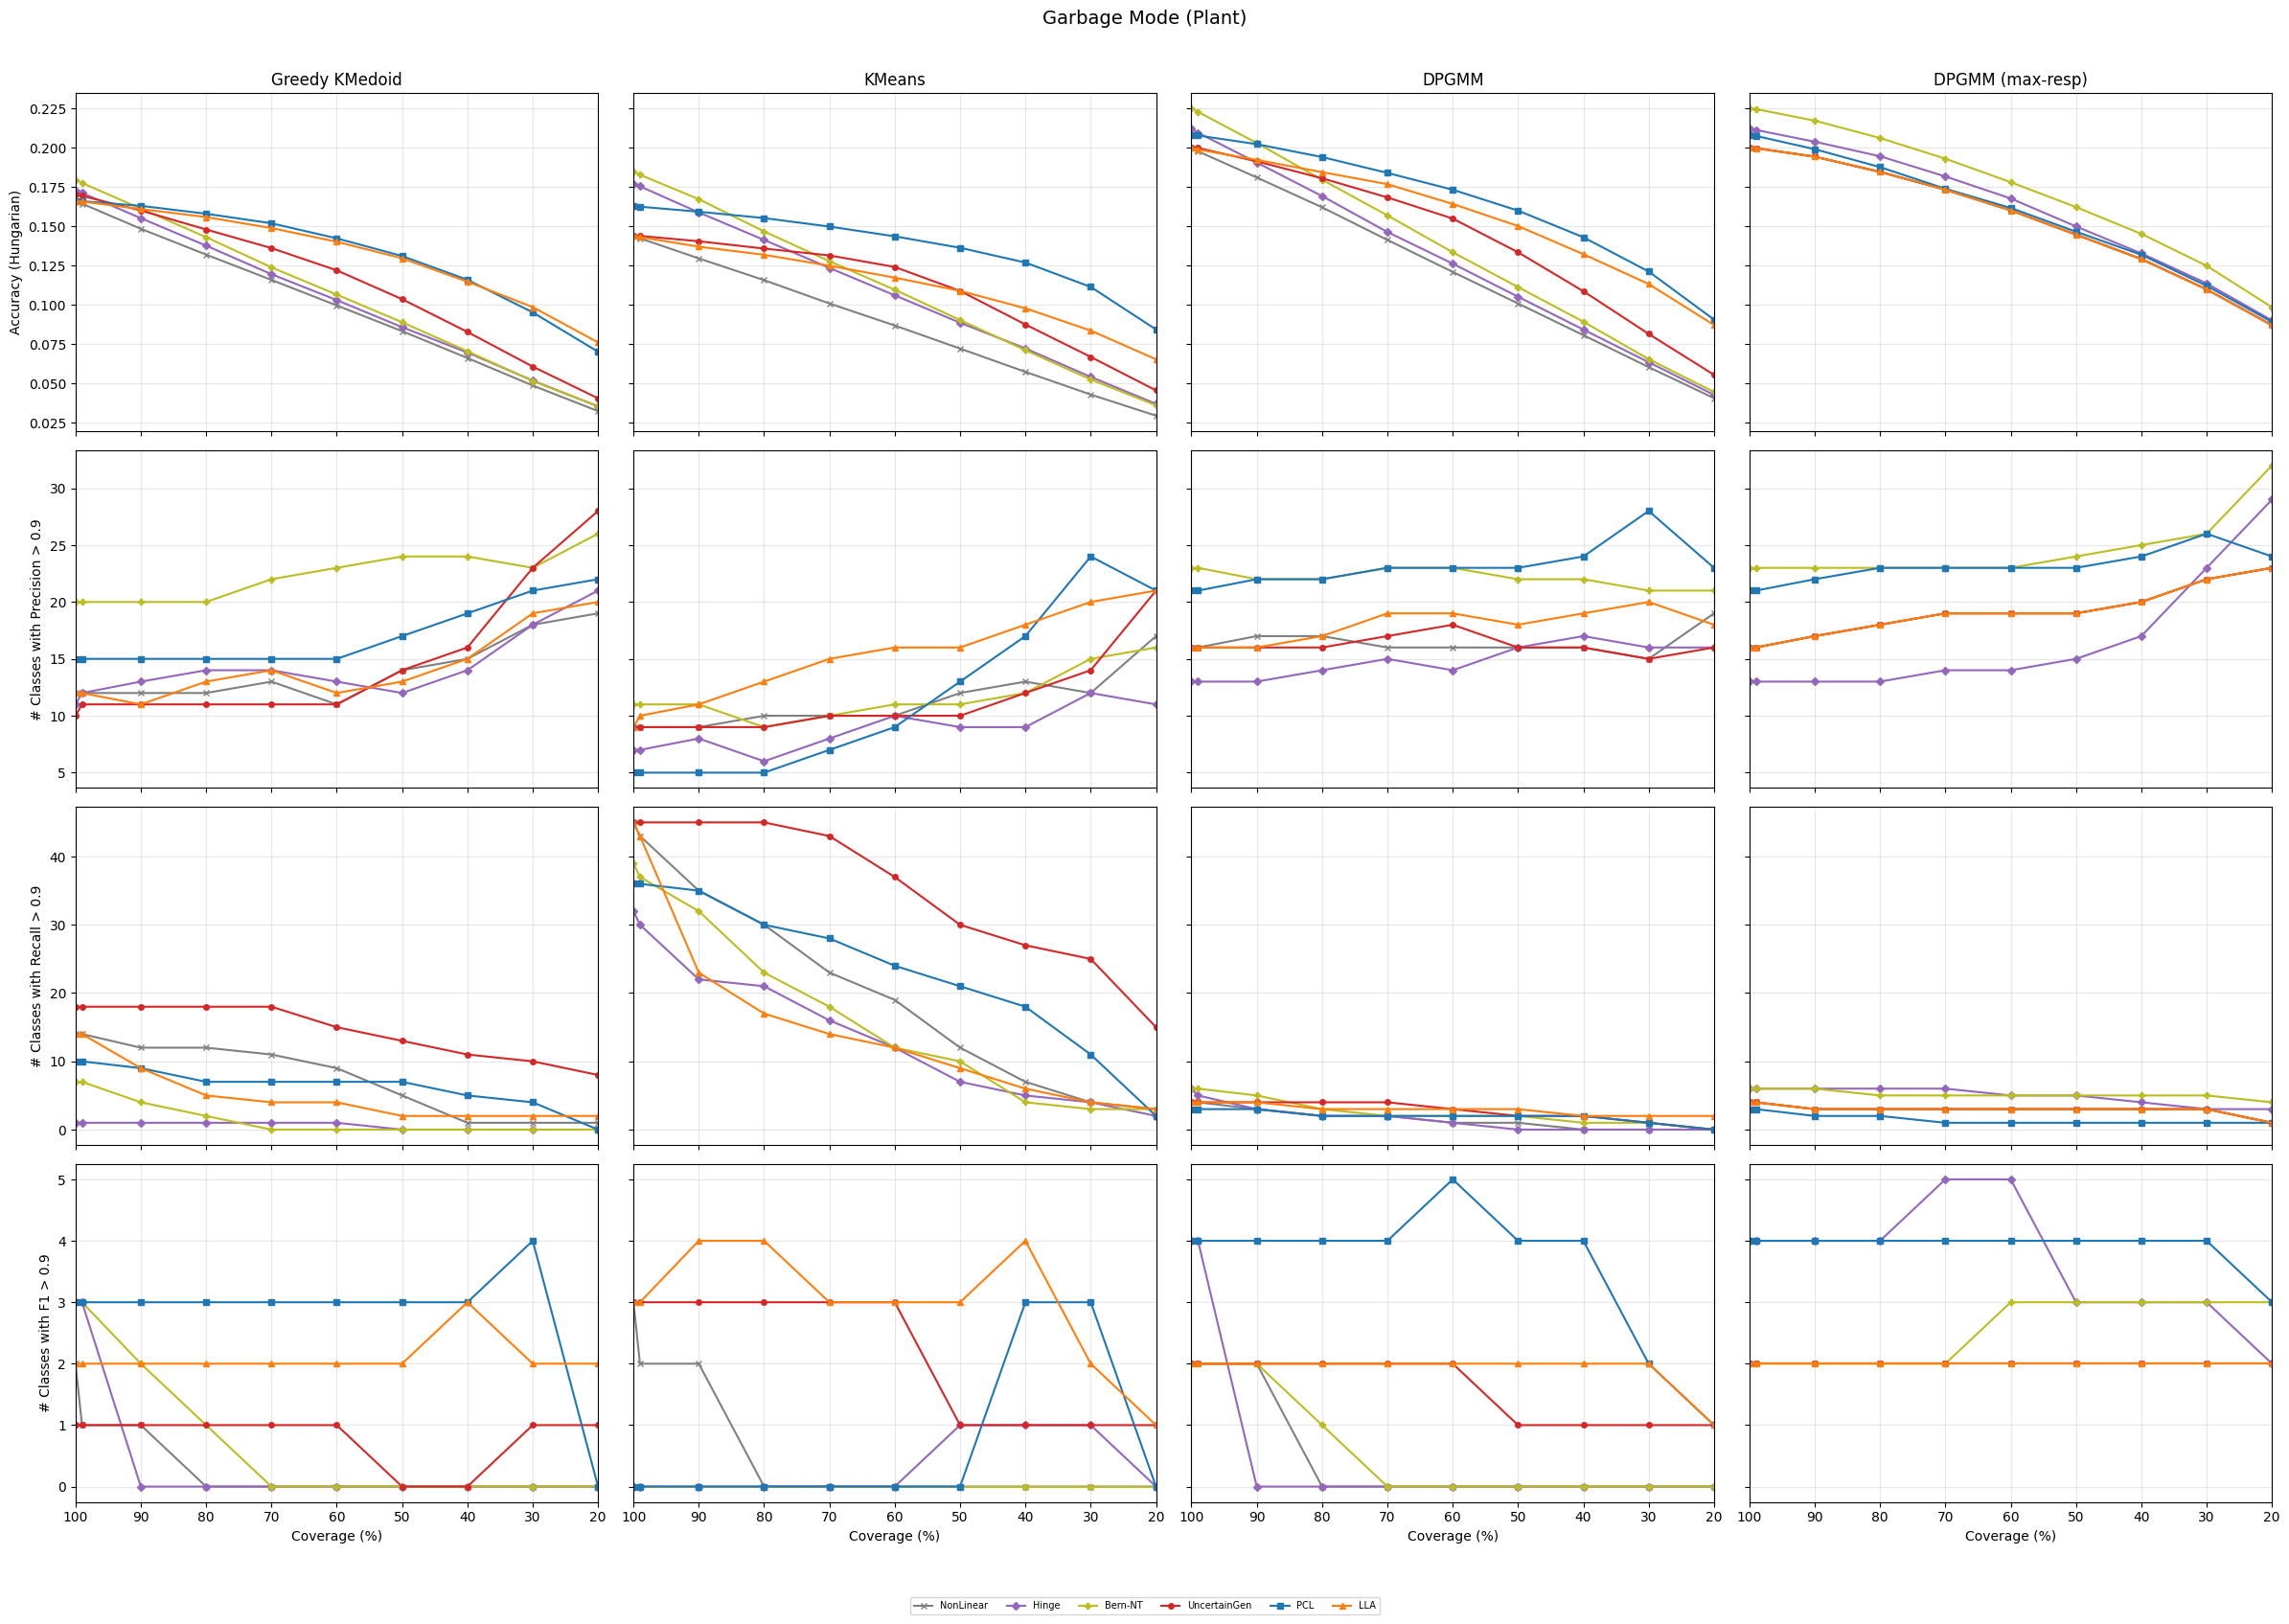

In [9]:
method_names = list(method_curves.keys())
METRICS = ['acc', 'precision', 'recall', 'f1']
METRIC_LABELS = {
    'acc': 'Accuracy (Hungarian)',
    'precision': '# Classes with Precision > 0.9',
    'recall': '# Classes with Recall > 0.9',
    'f1': '# Classes with F1 > 0.9',
}

n_methods = len(method_names)

# ── Discard mode ──
fig, axes = plt.subplots(len(METRICS), n_methods, figsize=(6 * n_methods, 4 * len(METRICS)),
                         sharex=True, sharey='row')
for col, method in enumerate(method_names):
    curves = method_curves[method]
    for row, metric_key in enumerate(METRICS):
        ax = axes[row, col]
        for m in MODEL_NAMES:
            covs = [r['coverage'] * 100 for r in curves[m]]
            vals = [r['discard'][metric_key] for r in curves[m]]
            ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                    markersize=4, linewidth=1.5)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, 20)
        if row == 0:
            ax.set_title(method, fontsize=12)
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric_key], fontsize=10)
        if row == len(METRICS) - 1:
            ax.set_xlabel('Coverage (%)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Discard Mode (Plant)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Garbage mode ──
fig, axes = plt.subplots(len(METRICS), n_methods, figsize=(6 * n_methods, 4 * len(METRICS)),
                         sharex=True, sharey='row')
for col, method in enumerate(method_names):
    curves = method_curves[method]
    for row, metric_key in enumerate(METRICS):
        ax = axes[row, col]
        for m in MODEL_NAMES:
            covs = [r['coverage'] * 100 for r in curves[m]]
            vals = [r['garbage'][metric_key] for r in curves[m]]
            ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                    markersize=4, linewidth=1.5)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, 20)
        if row == 0:
            ax.set_title(method, fontsize=12)
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric_key], fontsize=10)
        if row == len(METRICS) - 1:
            ax.set_xlabel('Coverage (%)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Garbage Mode (Plant)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary Tables

In [10]:
key_covs = [100, 80, 60, 40, 20]
cov_idx = {round(c * 100): i for i, c in enumerate(COVERAGES)}

for mode_key, mode_label in [('discard', 'DISCARD'), ('garbage', 'GARBAGE')]:
    print(f'\n{"="*100}')
    print(f'  MODE: {mode_label}')
    print(f'{"="*100}')
    for metric_key in METRICS:
        print(f'\n  {METRIC_LABELS[metric_key]}:')
        print(f'  {"Method":>18s}  {"Model":>12s}  ', end='')
        for c in key_covs:
            print(f'  {c:>5d}%', end='')
        print()
        print(f'  {"-"*75}')
        for method in method_names:
            curves = method_curves[method]
            for m in MODEL_NAMES:
                print(f'  {method:>18s}  {MODEL_LABELS[m]:>12s}  ', end='')
                for c in key_covs:
                    val = curves[m][cov_idx[c]][mode_key][metric_key]
                    print(f'  {val:6.3f}', end='')
                print()
            print()


  MODE: DISCARD

  Accuracy (Hungarian):
              Method         Model      100%     80%     60%     40%     20%
  ---------------------------------------------------------------------------
      Greedy KMedoid     NonLinear     0.199   0.198   0.199   0.199   0.193
      Greedy KMedoid         Hinge     0.243   0.243   0.243   0.245   0.250
      Greedy KMedoid       Bern-NT     0.302   0.301   0.299   0.298   0.296
      Greedy KMedoid  UncertainGen     0.199   0.223   0.250   0.264   0.280
      Greedy KMedoid           PCL     0.213   0.243   0.283   0.328   0.368
      Greedy KMedoid           LLA     0.199   0.221   0.257   0.306   0.393

              KMeans     NonLinear     0.144   0.145   0.145   0.144   0.148
              KMeans         Hinge     0.178   0.177   0.177   0.181   0.186
              KMeans       Bern-NT     0.186   0.185   0.184   0.179   0.182
              KMeans  UncertainGen     0.144   0.170   0.207   0.219   0.228
              KMeans           P

## 8. Rejected Samples Quality (Accuracy)

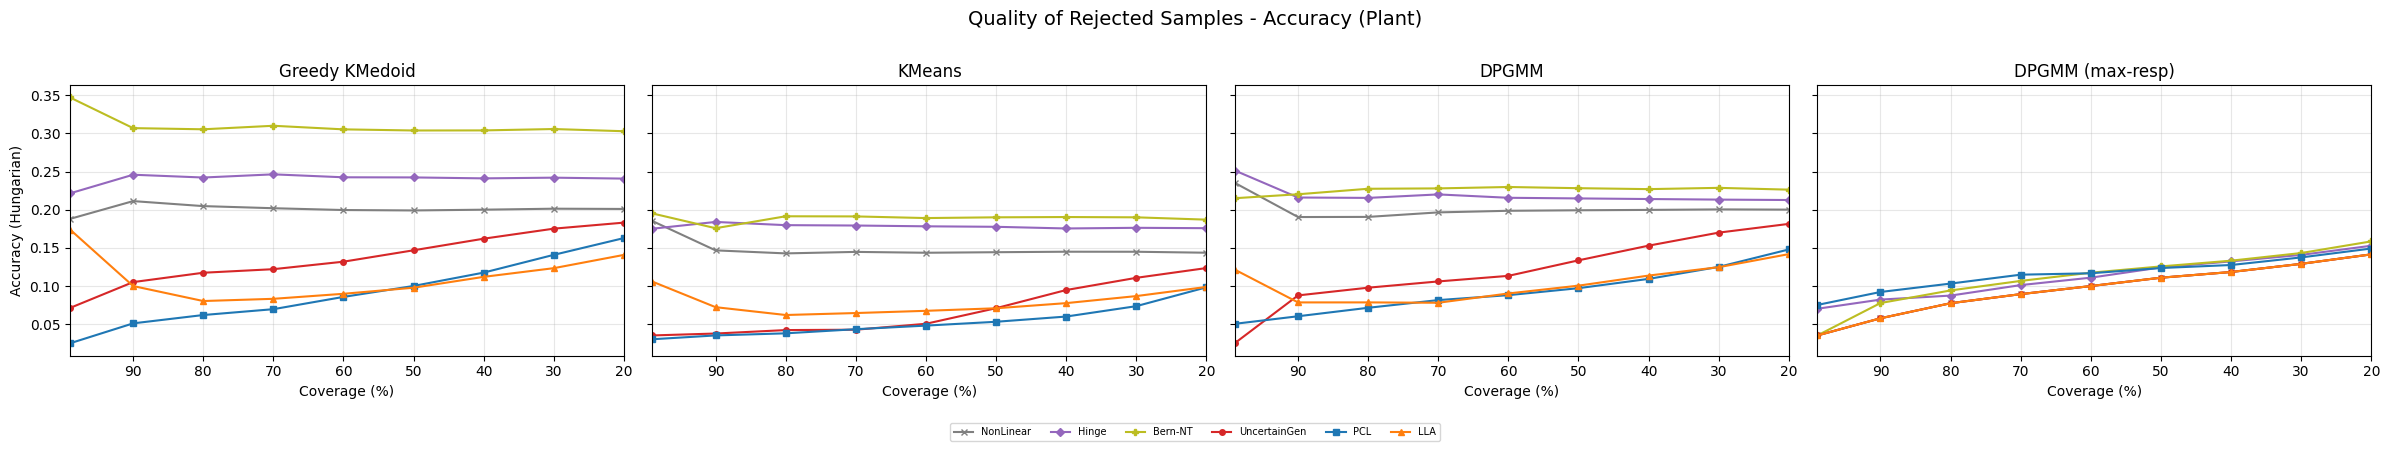

In [11]:
n_methods = len(method_names)
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 4),
                         sharex=True, sharey=True)

for col, method in enumerate(method_names):
    curves = method_curves[method]
    ax = axes[col]
    for m in MODEL_NAMES:
        covs = [r['coverage'] * 100 for r in curves[m] if r['coverage'] < 1.0]
        vals = [r['rejected']['acc'] for r in curves[m] if r['coverage'] < 1.0]
        ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                color=MODEL_COLORS[m], label=MODEL_LABELS[m], markersize=4)

    ax.grid(True, alpha=0.3)
    ax.set_xlim(99, 20)
    ax.set_title(method, fontsize=12)
    if col == 0:
        ax.set_ylabel(METRIC_LABELS['acc'], fontsize=10)
    ax.set_xlabel('Coverage (%)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Quality of Rejected Samples - Accuracy (Plant)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()